# 05 — Reading the rule: how two referee reports made the paper better

This notebook narrates the project's **final act** for someone who has not
followed it: how the invariant-amortization results of notebook 04 were turned
into a manuscript, torn apart twice by a detailed referee, and rebuilt into a
stronger and *more honest* paper. Everything here loads **cached outputs** from
`runs/` (nothing heavy is recomputed), so it executes in seconds and every
number matches `RESULTS.md` and the manuscript.

**Reading order for newcomers:** this notebook → `DECISIONS.md` (the one-page
executive-decision log) → `RESULTS.md` (every measured number) →
`manuscript/main.pdf`. Notebooks 01–03 are the historical v1 (the original
SSL-taxonomy attempt and its post-mortem); notebook 04 is the v2 "learn the
physics" arc this builds on.

In [1]:
# Environment & imports (CPU-light; everything loads cached JSON summaries).
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

def load(rel):
    with open(ROOT / rel) as fh:
        return json.load(fh)

TARGETS = ["damage_survival", "damage_fraction", "spreading_rate", "cone_fill"]
print("repo root:", ROOT)

repo root: /Users/michielrollier/Developer/GitHub/ssl-ecas


## §1 — Two referee rounds, three framings

The paper was reviewed twice by a detailed, strict, fair referee (full reports
in `manuscript/reviews/`, point-by-point answers in
`manuscript/response_to_referees.md`). Each round **changed the science**, not
just the wording:

| version | headline claim | verdict | what was wrong |
|---|---|---|---|
| v0 (submitted) | "A deep amortiser estimates dynamical invariants; five cheap statistics rival it" | **reject** | A broad negative proven against one constrained network, with under-powered statistics and no mechanistic baseline |
| v1 (round 1 revision) | "Interpretable methods dominate: read the rule, skip the network" | **major revision** | Our own tables contradicted "never beats" (the CNN led on 2 of 3 medians and added +0.32 survival information), and the reliability ceiling we cited was mathematically the wrong benchmark |
| v2 (current) | "**Rule reconstruction from a single diagram yields simulation-limited prediction**" | — | The claim the evidence actually supports |

The two decisive referee contributions:

1. **Round 1** demanded a transparent mechanistic baseline — *infer the rule
   table from the observed diagram, then simulate the perturbation experiment*.
   Building it produced the paper's central **positive** result (§2–§3 below).
2. **Round 2** caught that an independent-simulation estimator must be judged
   against the **independent-replicate agreement** (≈ 2·ICC−1), *not* the ICC
   reliability ceiling — a correction that made the result *stronger* (§3).

Every decision rule was committed numbers-free to `EVALUATION_CRITERIA.md`
**before** the corresponding measurement (revisions 7 and 8; auditable in git).

## §2 — Reading the rule off one diagram

A space–time diagram is not just a picture of behaviour — under this
benchmark's observation model (complete, noiseless, binary, deterministic,
synchronous, known radius) it *contains its own generator*. Every pair of
consecutive rows exposes thousands of `neighbourhood → next cell` transitions;
tabulating them rebuilds the rule table. For elementary CA that is 8 entries;
for the radius-two space, 32.

In [2]:
from caspectra.ca.eca import ECASimulator
from caspectra.ca.range_ca import RangeCA, embed_eca
from caspectra.eval.rule_inference import infer_rule, infer_rule_table

rng = np.random.default_rng(0)
ic = rng.integers(0, 2, size=127, dtype=np.uint8)

# Rule 110 (the famous Turing-complete ECA), one 63-step diagram:
diagram = ECASimulator(110).evolve(ic, 63)
rule, coverage, consistent = infer_rule(diagram, radius=1)
print(f"ECA:      generated by rule 110 -> inferred rule {rule}   "
      f"(table coverage {coverage:.0%}, consistent={consistent})")

# The same works in the 2^32-rule radius-two space (110 embedded):
r2rule = embed_eca(110, 2)
diagram2 = RangeCA(r2rule, 2).evolve(ic, 30)
rule2, cov2, _ = infer_rule(diagram2, radius=2)
print(f"radius-2: generated by rule {r2rule} -> inferred {rule2}   "
      f"(coverage {cov2:.0%}, exact={rule2 == r2rule})")

# The one failure mode: an under-exercised table. A diagram that dies leaves
# most neighbourhoods unobserved -- those entries must be *completed* (a prior).
dead = np.zeros((30, 63), dtype=np.uint8); dead[0, 3] = 1
_, observed, _ = infer_rule_table(dead, radius=1)
print(f"dead diagram: only {observed.sum()}/8 table entries observed -> "
      "unobserved entries need a completion prior (measured in §4)")

ECA:      generated by rule 110 -> inferred rule 110   (table coverage 100%, consistent=True)
radius-2: generated by rule 1023163644 -> inferred 1023163644   (coverage 100%, exact=True)
dead diagram: only 4/8 table entries observed -> unobserved entries need a completion prior (measured in §4)


Measured across the held-out rules: inference is **exact for 100% of
elementary and 97.5% of radius-two rules** from a single 127-wide diagram, and
coverage is complete for all ECA and 156/160 radius-two tables (the four
exceptions miss one entry each; swapping the completion prior between
default-0 / default-1 / empirical moves the median R² by less than 0.001 —
`runs/m4_range2/completion_policies/summary.json`).

Once the rule is recovered, the four damage-response statistics (survival,
fraction, spreading rate, cone fill — defined by *twin-run* perturbation
experiments that no single diagram directly shows) can simply be **simulated**.
The question the paper answers: how good is that, compared to learned and
hand-crafted estimators — and what is "as good as possible" anyway?

## §3 — What "as good as possible" means (the round-2 correction)

Each cached target is itself a **finite Monte-Carlo estimate** (256 twin runs),
so no predictor can agree with it perfectly. Round 2's key technical point:
*the ceiling depends on what kind of predictor you are*.

- A predictor of the **latent, noise-free** target mean $\theta$ is capped by
  the reliability $\mathrm{ICC} = \sigma_a^2/(\sigma_a^2+\sigma_e^2)$.
- But the mechanistic estimator returns a **fresh independent Monte-Carlo
  draw** $Y_2 = \theta + \varepsilon_2$. Its expected $R^2$ against the noisy
  cache $Y_1 = \theta + \varepsilon_1$ is
  $1 - 2\sigma_e^2/(\sigma_a^2+\sigma_e^2) = 2\,\mathrm{ICC} - 1$ — *lower*
  than ICC.

We had conflated the two. The demo below verifies the algebra empirically, then
loads the measured benchmarks: the mechanistic estimator sits **at the
replicate-agreement benchmark** against the noisy cache, and **at the ICC
ceiling** against a 16×-larger reference simulation — i.e. it is statistically
indistinguishable from *re-measuring the ground truth*.

In [3]:
from caspectra.eval.reliability import _icc_from_matrix, _mean_pairwise_agreement

# Synthetic check of the round-2 algebra: replicates with a known ICC.
sr = np.random.default_rng(1)
for target_icc in (0.994, 0.90):
    se = np.sqrt((1 - target_icc) / target_icc)          # sigma_a = 1
    x = sr.normal(0, 1, (1, 600)) + sr.normal(0, se, (20, 600))
    print(f"true ICC {target_icc:.3f}: measured ICC {_icc_from_matrix(x):.3f}, "
          f"replicate agreement {_mean_pairwise_agreement(x):.3f} "
          f"(2*ICC-1 = {2 * _icc_from_matrix(x) - 1:.3f})")

true ICC 0.994: measured ICC 0.993, replicate agreement 0.987 (2*ICC-1 = 0.987)
true ICC 0.900: measured ICC 0.901, replicate agreement 0.802 (2*ICC-1 = 0.802)


In [4]:
# The measured benchmarks (K=20 independent target replicates per rule).
for space, run in [("ECA", "runs/lever_a_local"), ("radius-2", "runs/m4_range2")]:
    rel = load(f"{run}/reliability/summary.json")["per_feature"]
    mech = load(f"{run}/mechanistic_eval/summary.json")
    print(f"\n{space}: mechanistic estimator vs the two benchmarks")
    print(f"{'target':>16} | {'vs cache':>8} {'agreement':>9} | {'vs 4096-ref':>11} {'ICC':>6}")
    for t in TARGETS:
        print(f"{t:>16} | {mech['per_feature_r2'][t]:8.4f} {rel[t]['agreement_r2']:9.4f} | "
              f"{mech['per_feature_r2_vs_reference'][t]:11.4f} {rel[t]['icc']:6.4f}")


ECA: mechanistic estimator vs the two benchmarks
          target | vs cache agreement | vs 4096-ref    ICC
 damage_survival |   0.9850    0.9871 |      0.9943 0.9936
 damage_fraction |   0.9997    0.9975 |      0.9999 0.9988
  spreading_rate |   1.0000    0.9991 |      1.0000 0.9995
       cone_fill |   0.9985    0.9984 |      0.9994 0.9992

radius-2: mechanistic estimator vs the two benchmarks
          target | vs cache agreement | vs 4096-ref    ICC
 damage_survival |   0.9765    0.9739 |      0.9877 0.9870
 damage_fraction |   0.9966    0.9965 |      0.9983 0.9983
  spreading_rate |   0.9970    0.9968 |      0.9984 0.9984
       cone_fill |   0.9849    0.9594 |      0.9921 0.9796


Read the table columns in pairs: **vs cache ≈ agreement** (the correct
benchmark for a fresh simulation) and **vs 4096-pair reference ≈ ICC** (the
ceiling, reachable only when the comparison target is nearly noise-free). The
apparent "shortfall" in the round-1 draft was entirely the comparison target's
own noise. This is the paper's central positive result: *under the matched
observation model, reading the rule and re-running the experiment is as good as
re-measuring the truth.*

## §4 — The estimator race, per target

Round 2's other integrity fix: our "interpretable methods dominate" headline
contradicted our own tables. The honest per-target picture (rule-bootstrap 95%
CIs; CNN mean ± s.d. over five training seeds; verdicts per the pre-registered
rules — superiority needs ΔR² ≥ 0.10 with CI excluding 0, equivalence needs the
90% CI inside ±0.05, anything else is *inconclusive*):

In [5]:
for space, run in [("ECA (18 held-out orbits)", "runs/lever_a_local"),
                   ("radius-2 (160 held-out rules)", "runs/m4_range2")]:
    s = load(f"{run}/full_table/summary.json")
    print(f"\n=== {space} ===")
    print(f"{'target':>16} | {'mechanistic':>22} | {'5 statistics':>22} | {'CNN (5 seeds)':>14}")
    for t in TARGETS:
        me, gb = s["per_method_r2"]["mechanistic"][t], s["per_method_r2"]["gbm"][t]
        cs = s["cnn_seed_spread"][t]
        print(f"{t:>16} | {me['r2']:.3f} [{me['ci95'][0]:+.2f},{me['ci95'][1]:+.2f}] "
              f"| {gb['r2']:.3f} [{gb['ci95'][0]:+.2f},{gb['ci95'][1]:+.2f}] "
              f"| {cs['mean']:.3f}±{cs['std']:.3f}")
    print("CNN vs 5 statistics, verdicts at delta=0.05:")
    for t, d in s["pairs"]["cnn_minus_gbm"].items():
        print(f"    {t:>16}: dR2={d['delta_r2']:+.3f} CI{d['ci95']} -> "
              f"{d['verdict_by_delta']['0.05']}")


=== ECA (18 held-out orbits) ===
          target |            mechanistic |           5 statistics |  CNN (5 seeds)
 damage_survival | 0.985 [+0.89,+1.00] | 0.708 [-0.54,+0.92] | 0.700±0.018
 damage_fraction | 1.000 [+1.00,+1.00] | 0.924 [-0.84,+0.96] | 0.789±0.038
  spreading_rate | 1.000 [+1.00,+1.00] | 0.965 [-0.52,+1.00] | 0.956±0.015
       cone_fill | 0.999 [+0.99,+1.00] | 0.929 [+0.85,+0.99] | 0.916±0.019
CNN vs 5 statistics, verdicts at delta=0.05:
           cone_fill: dR2=-0.034 CI[-0.2939, 0.0584] -> inconclusive
     damage_fraction: dR2=-0.120 CI[-0.4169, 0.6289] -> inconclusive
     damage_survival: dR2=-0.042 CI[-0.5494, 0.2592] -> inconclusive
      spreading_rate: dR2=+0.000 CI[-0.0471, 0.4227] -> equivalent

=== radius-2 (160 held-out rules) ===
          target |            mechanistic |           5 statistics |  CNN (5 seeds)
 damage_survival | 0.977 [+0.93,+0.99] | 0.809 [+0.55,+0.91] | 0.874±0.009
 damage_fraction | 0.997 [+1.00,+1.00] | 0.909 [+0.88,+0.93] | 0.

In [6]:
# Does the network carry information the five statistics miss? (stacking)
st = load("runs/m4_range2/stacking/summary.json")["increments"]
print("Cross-fitted incremental R2 (radius-2), base model -> stacked model:")
for t in TARGETS:
    d = st["cnn_over_features"][t]
    print(f"  CNN over 5 stats, {t:>16}: {d['incremental_r2']:+.3f} CI{d['ci95']}  "
          f"({d['base_model_r2']:.3f} -> {d['stacked_model_r2']:.3f})"
          f"{'   <-- real complementarity' if d['adds_value'] else ''}")
print("  (the reverse direction, 5 stats over CNN: nothing significant)")

Cross-fitted incremental R2 (radius-2), base model -> stacked model:
  CNN over 5 stats,  damage_survival: +0.320 CI[0.2322, 0.4787]  (0.556 -> 0.876)   <-- real complementarity
  CNN over 5 stats,  damage_fraction: +0.034 CI[0.0108, 0.0579]  (0.851 -> 0.885)   <-- real complementarity
  CNN over 5 stats,   spreading_rate: +0.030 CI[0.0058, 0.0557]  (0.839 -> 0.869)   <-- real complementarity
  CNN over 5 stats,        cone_fill: +0.080 CI[-0.1105, 0.2895]  (0.136 -> 0.210)
  (the reverse direction, 5 stats over CNN: nothing significant)


Three honest take-aways, exactly as the manuscript now states them:

1. **No stable ordering** between the CNN and the five statistics — the CNN is
   (sub-margin) ahead on survival, the baseline is *superior* on cone fill, the
   rest are inconclusive/equivalent. "Never beats" was false and is retired.
2. The CNN **does** add large, real survival information beyond the five
   statistics (stacked model 0.56 → 0.88) — the least texture-like target.
3. The mechanistic estimator is at its benchmark on every target; no comparison
   anywhere favours a direct method over it.

## §5 — When reading fails: the identifiability phase diagram

The referee's most valuable request: don't report a single recovery percentage —
map **when** rule reading works. The sweep below (radius-2 held-out rules;
frozen CNN, no retraining) degrades the observation along four axes. This
figure is now the paper's scope statement in graphical form — and it defines
the *next* work package (§8).

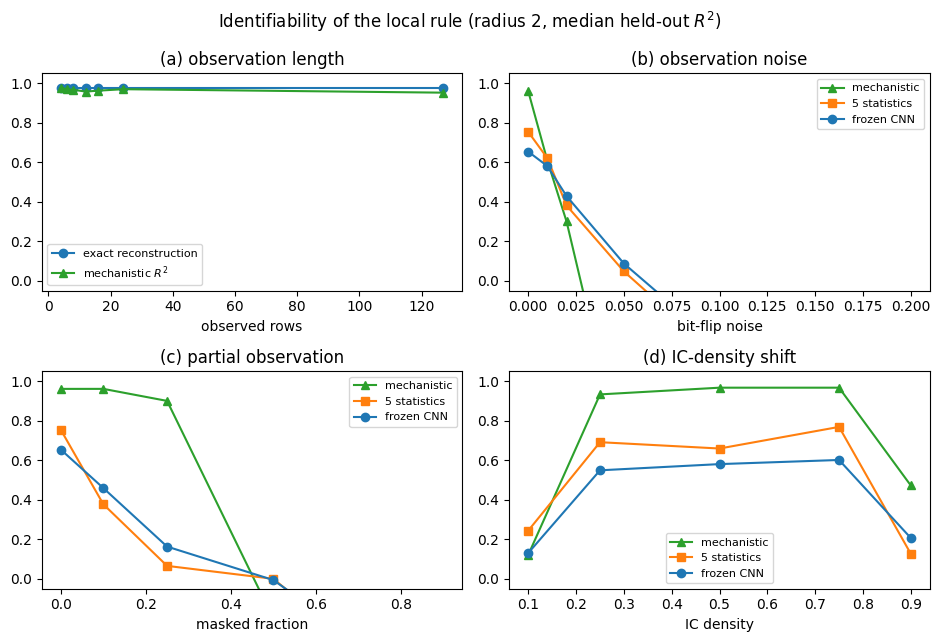

noise crossover: mechanistic [0.959, 0.6076, 0.3007, -0.9242] vs frozen CNN [0.654, 0.5808, 0.4294, 0.0878] at noise [0.0, 0.01, 0.02, 0.05]


In [7]:
ident = load("runs/m4_range2/identifiability/summary.json")["sweeps"]
fig, ax = plt.subplots(2, 2, figsize=(9.5, 6.5))
a = ax[0, 0]
a.plot(ident["rows"]["values"], ident["rows"]["exact"], "o-", label="exact reconstruction")
a.plot(ident["rows"]["values"], ident["rows"]["mechanistic"], "^-", c="C2", label="mechanistic $R^2$")
a.set_xlabel("observed rows"); a.set_title("(a) observation length"); a.legend(fontsize=8)
a.set_ylim(-0.05, 1.05)
for key, panel, xlabel, title in [
    ("noise", ax[0, 1], "bit-flip noise", "(b) observation noise"),
    ("mask", ax[1, 0], "masked fraction", "(c) partial observation"),
    ("density", ax[1, 1], "IC density", "(d) IC-density shift"),
]:
    s = ident[key]
    panel.plot(s["values"], s["mechanistic"], "^-", c="C2", label="mechanistic")
    panel.plot(s["values"], s["baseline"], "s-", c="C1", label="5 statistics")
    panel.plot(s["values"], s["cnn"], "o-", c="C0", label="frozen CNN")
    panel.set_xlabel(xlabel); panel.set_title(title); panel.legend(fontsize=8)
    panel.set_ylim(-0.05, 1.05)
fig.suptitle("Identifiability of the local rule (radius 2, median held-out $R^2$)")
fig.tight_layout(); plt.show()

n = ident["noise"]
print("noise crossover: mechanistic", n["mechanistic"][:4], "vs frozen CNN", n["cnn"][:4],
      f"at noise {n['values'][:4]}")

**The three regimes:** with clean full observation, reconstruction is
exact from as few as 4 rows and the mechanistic estimator holds its benchmark —
no room for amortization. At **~2–5% bit-flip noise** the deterministic
inverter collapses (a deterministic table has no noise model — one corrupted
transition flips an entry) and the frozen CNN *overtakes* it; the same happens
beyond **~40% masking**. At extreme IC densities the diagram no longer
exercises the table and everything degrades. The recommendation "read the rule"
holds **inside** the matched-observation regime and is explicitly not asserted
outside it.

## §6 — The descriptive by-products, at the strength the evidence supports

Two side results survived both rounds, with their language corrected to match
their validation:

**The "complex-behaviour landscape" is now a *damage-signature landscape*.**
On ECA, where literature ground truth exists, the damage-signature criterion is
excellent — but the *independent* localized-seed glider detector turns out to
be the weak instrument, which is exactly why the radius-2 band is not promoted
to a "glider region":

In [8]:
g1 = load("runs/analysis/glider_validation/summary_r1.json")
g2 = load("runs/analysis/glider_validation/summary_r2.json")
def row(name, c):
    print(f"  {name:>34}: sens {c['sensitivity']:.2f}  spec {c['specificity']:.2f}  "
          f"prec {c['precision']:.2f}  balanced-acc {c['balanced_accuracy']:.2f}  "
          f"(n={c['n']}, positives={c['n_positive']})")
print(f"ECA damage-signature set: {g1['eca_damage_signature_set']} "
      f"(literature class-IV truth: {g1['eca_literature_class_iv_truth']})")
row("damage signature vs literature", g1["damage_signature_vs_literature_confusion"])
row("independent detector vs literature", g1["detector_vs_literature_confusion"])
print(f"radius-2: {g2['damage_signature_complex_fraction']:.1%} of rules meet the "
      "damage-signature criterion, but the detector is near-useless there:")
row("detector vs damage signature", g2["detector_vs_damage_signature_confusion"])

ECA damage-signature set: [54, 106, 110] (literature class-IV truth: [54, 110])
      damage signature vs literature: sens 1.00  spec 0.99  prec 0.67  balanced-acc 0.99  (n=88, positives=2)
  independent detector vs literature: sens 0.50  spec 0.92  prec 0.17  balanced-acc 0.71  (n=64, positives=2)
radius-2: 8.3% of rules meet the damage-signature criterion, but the detector is near-useless there:
        detector vs damage signature: sens 0.30  spec 0.49  prec 0.05  balanced-acc 0.39  (n=231, positives=20)


In [9]:
# The spatial-map claim, corrected to its registered verdict:
nu = load("runs/lever_a_shallow/nuca_local_gt/summary.json")
sp = nu["mean_spearman_to_local_gt"]
print(f"CNN map {sp['cnn']:.3f} vs validation-selected handcrafted "
      f"{sp['handcrafted_val_selected']:.3f} (Spearman to independent local ground truth)")
print(f"difference {nu['cnn_minus_val_selected_handcrafted_test']:+.3f}, "
      f"CI95 {nu['ci95']}, CI90 {nu['ci90']}  ->  verdict: {nu['verdict'].upper()}")
print("(not a 'tie': equivalence would need the 90% CI inside ±0.05; "
      "not superiority: the point estimate is below the 0.10 margin)")

CNN map 0.673 vs validation-selected handcrafted 0.605 (Spearman to independent local ground truth)
difference +0.047, CI95 [-0.0025, 0.1016], CI90 [0.0045, 0.0918]  ->  verdict: INCONCLUSIVE
(not a 'tie': equivalence would need the 90% CI inside ±0.05; not superiority: the point estimate is below the 0.10 margin)


## §7 — What reading the rule costs

Accuracy is not the only utility criterion (round-2 concern 11). Per-diagram
latency and the accuracy-vs-Monte-Carlo-budget curve:

In [10]:
p = load("runs/m4_range2/compute_pareto/summary.json")
print(f"{'MC pairs':>9} | {'ms/diagram':>10} | {'median R2':>9}")
for c in p["mechanistic_curve"]:
    print(f"{c['n_pairs']:>9} | {c['latency_s_per_diagram']*1e3:>10.1f} | {c['median_r2']:>9.4f}")
print(f"\nCNN forward pass: {p['cnn_latency_s_single']*1e3:.1f} ms   "
      f"5 statistics: {p['five_stat_latency_s_per_diagram']*1e3:.1f} ms")
print(f"one-time: CNN training ~{p['cnn_one_time_train_s']/60:.0f} min/seed, "
      f"GBM fit {p['five_stat_one_time_fit_s']:.0f} s")
print(f"break-even vs mechanistic@256: ~{p['breakeven_queries_vs_mechanistic']} queries")
print("\nNote the one-sidedness: at 16 pairs (17 ms) the mechanistic estimator's "
      "0.924 already beats both direct estimators at ANY budget.")

 MC pairs | ms/diagram | median R2
       16 |       17.4 |    0.9244
       32 |       32.3 |    0.9659
       64 |       73.5 |    0.9787
      128 |      143.1 |    0.9886
      256 |      283.5 |    0.9911

CNN forward pass: 2.2 ms   5 statistics: 1.4 ms
one-time: CNN training ~22 min/seed, GBM fit 15 s
break-even vs mechanistic@256: ~4729 queries

Note the one-sidedness: at 16 pairs (17 ms) the mechanistic estimator's 0.924 already beats both direct estimators at ANY budget.


## §8 — Scoreboard, and what comes next

**What the paper now claims (and no more):**

1. Under the matched observation model, one diagram identifies the rule
   (100% / 97.5%) and reconstruct-then-simulate predicts the damage response at
   the accuracy of re-measuring it (§3).
2. The two direct estimators admit no stable ordering; the CNN's real
   contribution is survival information beyond texture (+0.32 incremental R²).
3. Rule reading fails predictably — noise ≳ 2–5%, masking ≳ 40%, extreme
   densities — and there the frozen CNN already degrades more gracefully (§5).
4. The landscape is a damage-signature landscape; the spatial-map comparison is
   inconclusive; both stated at exactly the strength their validation supports.

**Next work package (pre-registration rev 9, `DECISIONS.md` 2026-07-05): the
identifiability frontier.** The manuscript's own Discussion poses the open
question — where exact reading fails, do (F1) a *Bayesian rule-posterior
simulator* (per-entry Beta–Bernoulli posterior over the table under a bit-flip
noise model, then posterior-predictive simulation) and (F2) a small *learned
rule-reader → simulator* (a CNN that predicts table bits from noisy diagrams,
the referee's thrice-requested comparator) restore simulation-limited accuracy?
Results are held as a round-3 extension of the manuscript: an upgraded version
of the §5 phase diagram with the new estimator curves.